In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [28]:
data = pd.read_csv(r"C:\Users\medin\Downloads\house_price_regression_dataset.csv")
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [30]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [31]:
data.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [32]:
data.duplicated().sum()


np.int64(0)

Text(0.5, 1.0, 'Number of Bedrooms vs House Price')

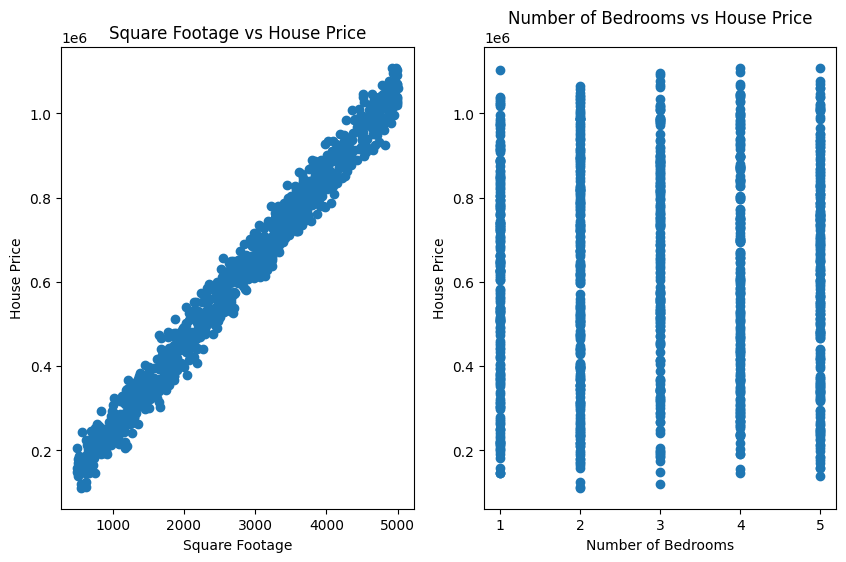

In [33]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(data['Square_Footage'],data['House_Price'])
plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.title('Square Footage vs House Price')
plt.subplot(1,2,2)
plt.scatter(data['Num_Bedrooms'],data['House_Price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('House Price')
plt.title('Number of Bedrooms vs House Price')

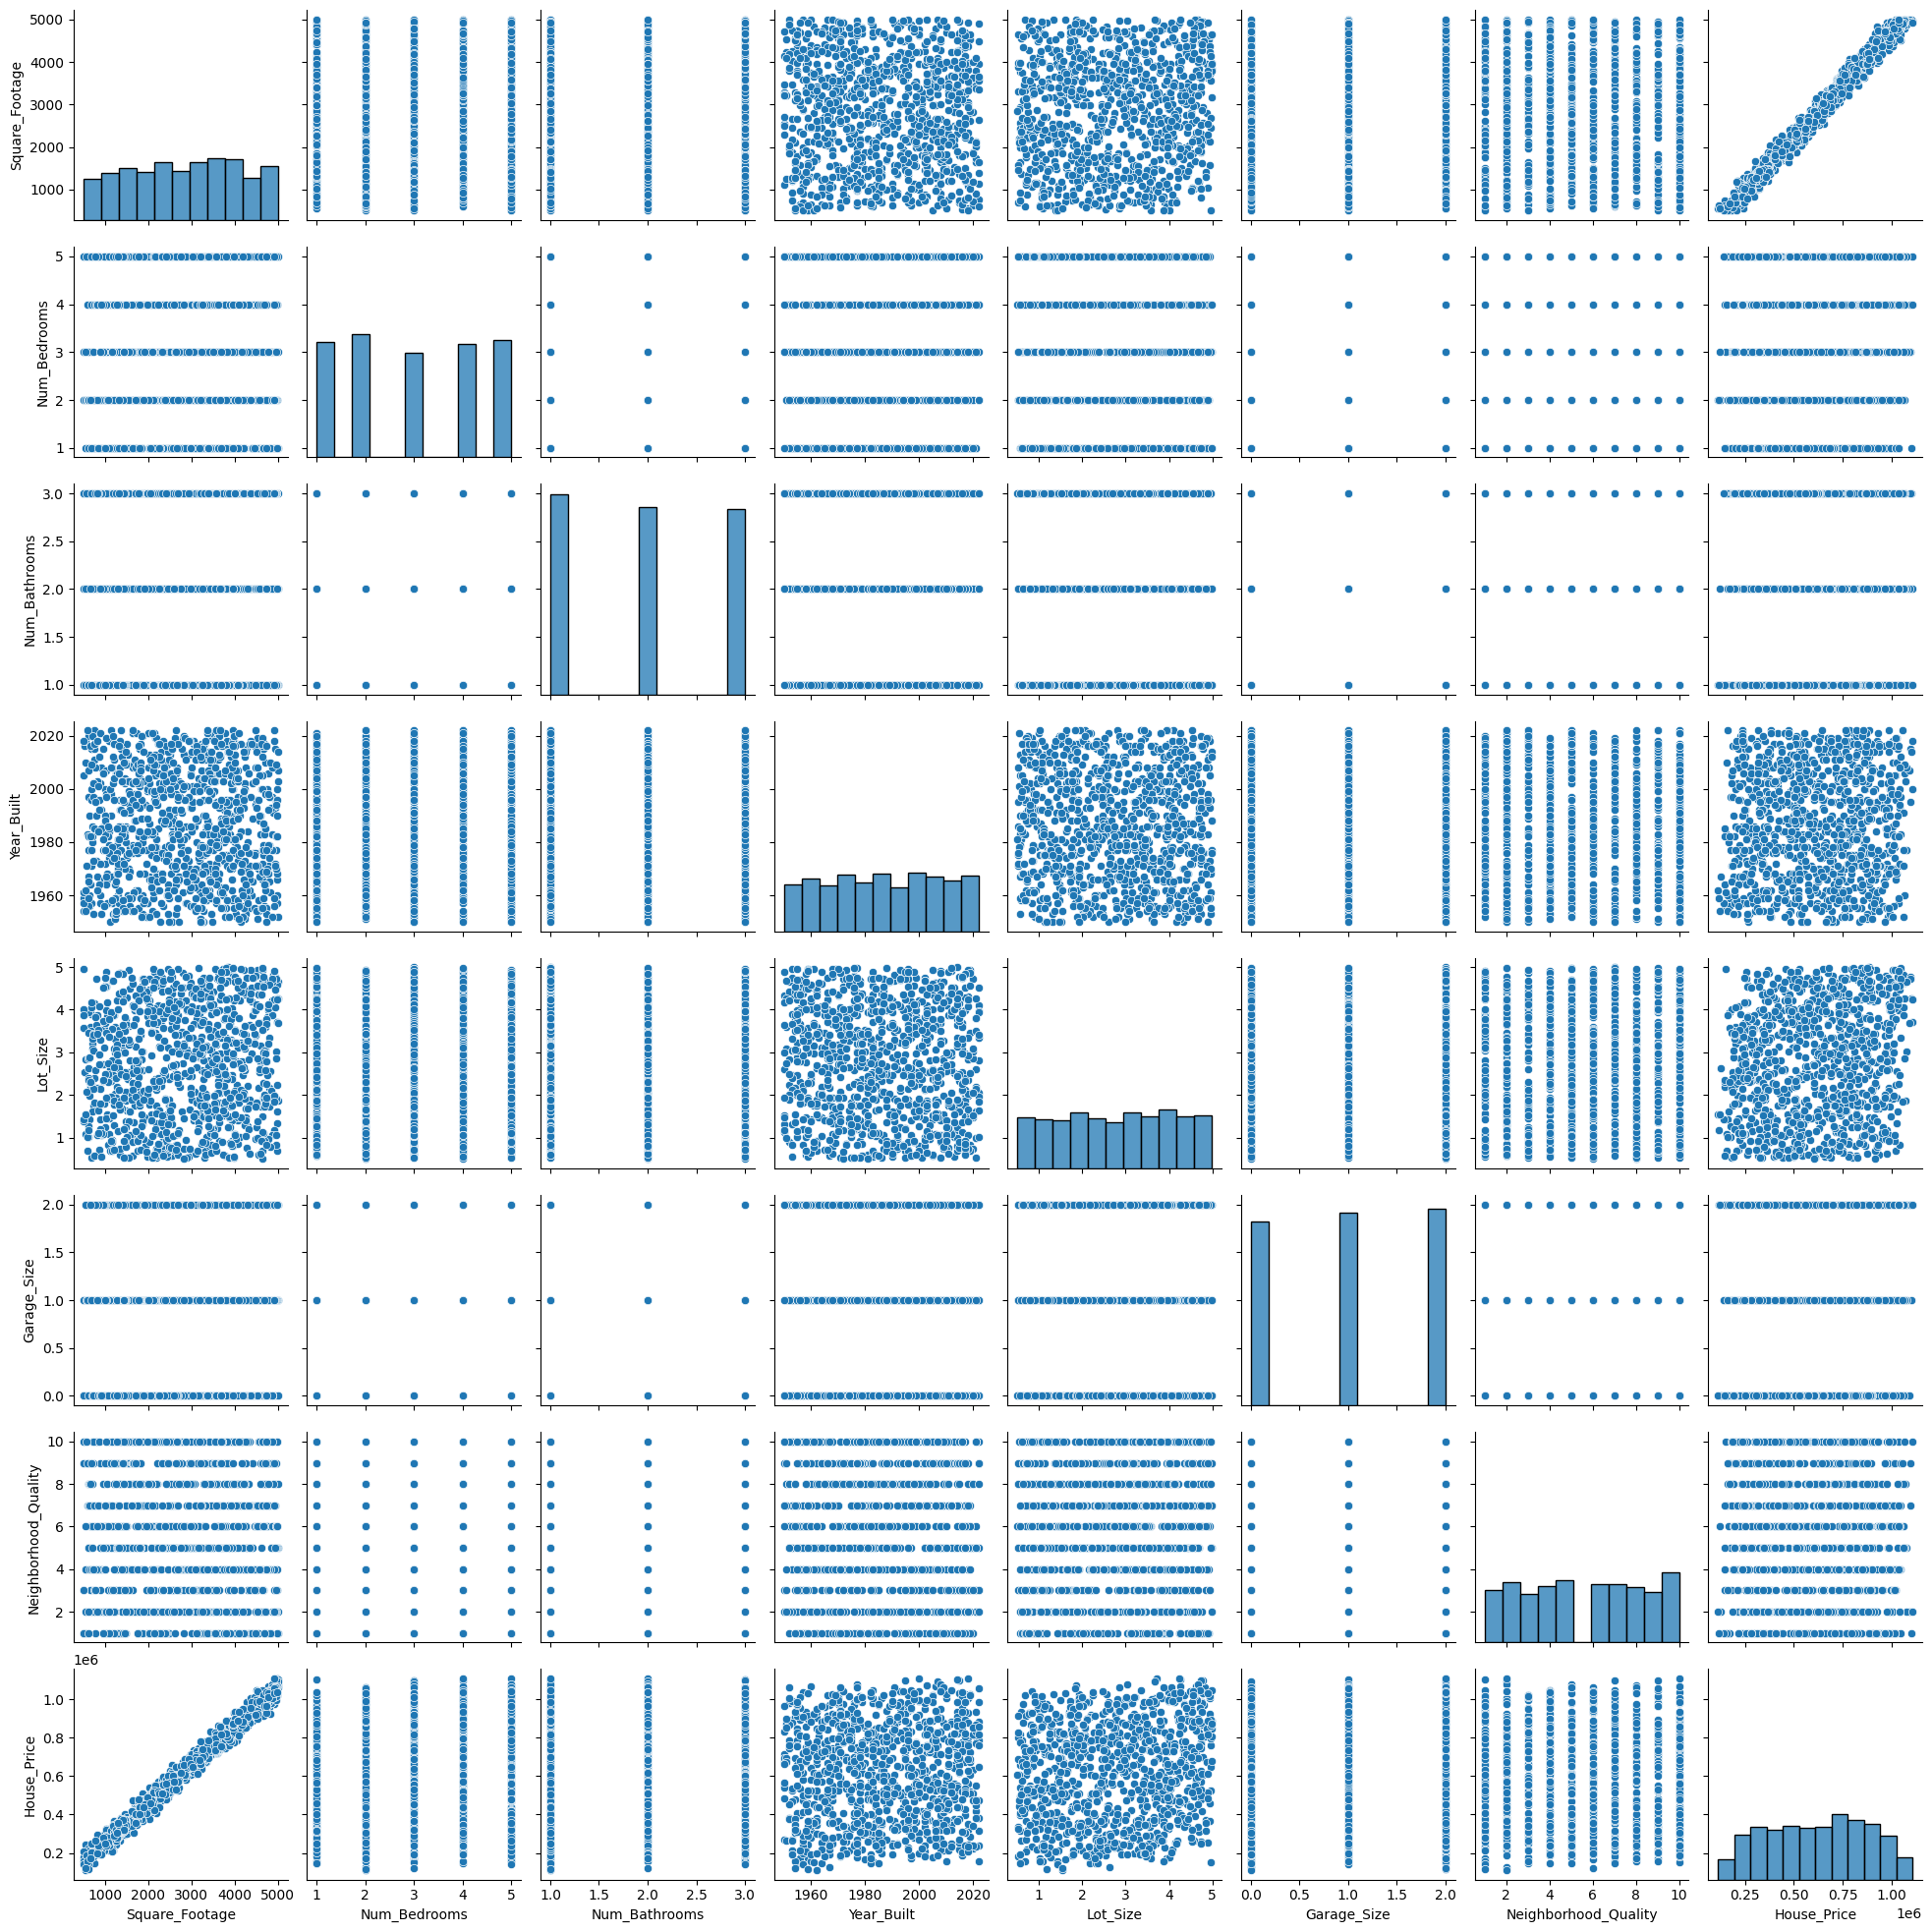

In [34]:
sns.pairplot(data)

<Axes: >

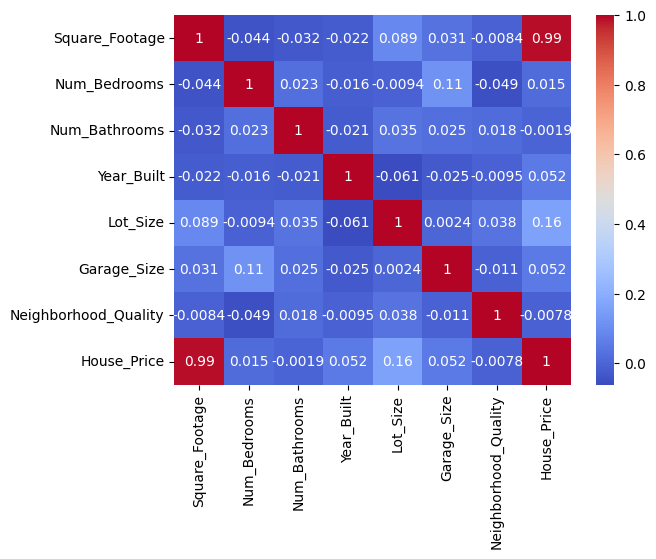

In [35]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

In [36]:
# scaler = MinMaxScaler()
# data['House_Price'] = scaler.fit_transform(data[['House_Price']])


In [37]:
# scaler2 = StandardScaler()
# data['Square_Footage'] = scaler2.fit_transform(data[['Square_Footage']])
# data['Square_Footage'].min(), data['Square_Footage'].max()

In [38]:
x = np.array(data.drop('House_Price',axis=1))
y = data['House_Price']

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred = linear_model.predict(x_test)
y_pred

array([ 868687.10747903,  490337.89825447,  945667.12422537,
       1033402.87599247,  776698.77390587,  732444.09335308,
        995051.99156272,  885174.76924362,  796730.53817137,
        931741.09209272,  759486.73376772,  645409.40410205,
        217706.20688729, 1047436.52669427,  536985.283711  ,
        187868.55343105,  456819.02346557,  357933.98497768,
        743138.35721931,  362670.94796792,  775101.05248527,
        478174.42921702,  680966.06345079,  889457.56001471,
        447158.93387226,  396997.78641332,  454334.22026962,
        442837.53540887,  187336.81096629,  491668.18070411,
        279715.81740979,  895941.0005743 ,  783583.19778842,
        352212.91737968,  479313.284656  ,  766612.6601435 ,
        474636.25109508,  572446.37288032,  303449.70619643,
        154599.27036073,  304341.05092125,  299677.00775284,
        508575.91105888,  309977.51725285, 1082131.76994762,
       1011343.63575232,  760359.56460958,  807425.57445877,
       1025548.17009414,

In [42]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {MAE}")
print(f"Mean Squared Error: {MSE}")
print(f"Root Mean Squared Error: {RMSE}")
print(f"R-squared: {R2}")

Mean Absolute Error: 8174.583600008711
Mean Squared Error: 101434798.5056678
Root Mean Squared Error: 10071.484424138669
R-squared: 0.9984263636823408


In [43]:
linear_model.coef_, linear_model.intercept_


(array([  199.5132451 , 10225.20442447,  8208.43477773,   993.53717106,
        14885.38441462,  5146.14838284,   115.06859524]),
 np.float64(-2010567.420270212))

In [44]:
y_test_pred = linear_model.predict([[4272,3,3,2016,4.75301384940203,1,6]])
y_test_pred

array([976612.01549983])

In [45]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train,y_train)
tree_pred = tree_model.predict(x_test)


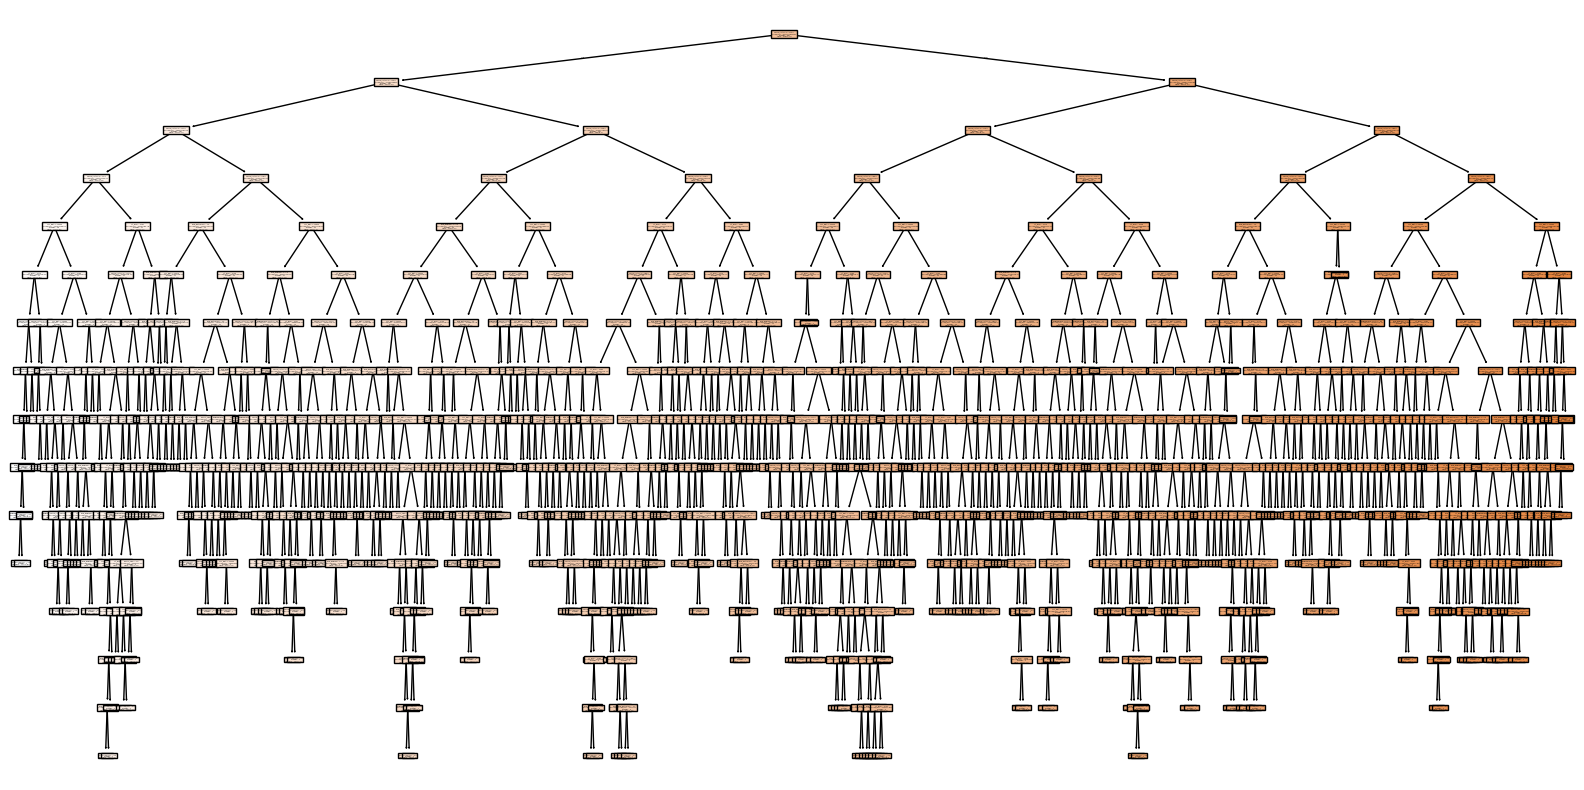

In [46]:
from sklearn.tree import plot_tree
tree_model.fit(x_train,y_train)
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=data.drop('House_Price',axis=1).columns, filled=True)
plt.show()

In [47]:
import joblib
joblib.dump(tree_model, r"C:\Users\medin\Downloads\house_price_tree_model.pkl")

['C:\\Users\\medin\\Downloads\\house_price_tree_model.pkl']